# PA-10 — Pipeline Complète de Traitement Audio
**Sprint 5 | Équipe P07 | Projet Stellantis**

Pipeline intégrée complète :

1. **VAD** (Silero) — détection des segments de parole
2. **Diarisation** (pyannote) — attribution des locuteurs
3. **Agent IA / Wake word** (PA-23) — détection "Hey Assistant"
4. **Conducteur / Passager** (PA-12) — enrôlement vocal + similarité cosinus
5. **Genre + Âge** (PA-45) — pitch F0 + audeering wav2vec2
6. **DER** — calcul sur vérité terrain RTTM
7. **Export JSON unifié** + timeline

*Détection d'émotion : non implémentée dans cette version.*

**Prérequis :** token HuggingFace configuré dans les secrets Colab (`HF_TOKEN`).

## 1. Installation des dépendances
⚠️ Redémarrer le runtime après cette cellule.

In [ ]:
!pip install -q pyannote.audio silero-vad faster-whisper librosa soundfile pydub datasets
!pip install -q transformers safetensors huggingface_hub
!apt-get install -q ffmpeg
print('✅ Installation OK — redémarre le runtime !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Chargement des modèles

In [ ]:
import torchaudio, torch, torch.nn as nn, numpy as np, os, json, datetime, soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import find_peaks
from pyannote.audio import Pipeline, Model, Inference
from faster_whisper import WhisperModel
from pydub import AudioSegment
from transformers import Wav2Vec2Processor, Wav2Vec2Config
from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2Model
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download
from google.colab import userdata, files

# Patch compatibilité torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

HF_TOKEN = userdata.get('HF_TOKEN')

# pyannote diarisation
diarization_pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1', token=HF_TOKEN)
print('✅ pyannote diarisation chargé')

# pyannote embedding
embedding_model = Inference(
    Model.from_pretrained('pyannote/embedding', token=HF_TOKEN),
    window='whole')
print('✅ pyannote embedding chargé')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad', model='silero_vad',
    force_reload=False, trust_repo=True)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('✅ Silero VAD chargé')

# faster-whisper base INT8
device_str   = 'cuda' if torch.cuda.is_available() else 'cpu'
compute_type = 'float16' if device_str == 'cuda' else 'int8'
whisper_model = WhisperModel('base', device=device_str, compute_type=compute_type)
print(f'✅ faster-whisper base chargé ({device_str}, {compute_type})')

# Modèle genre+âge audeering (architecture custom)
class ModelHead(nn.Module):
    def __init__(self, config, num_labels):
        super().__init__()
        self.dense    = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout  = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, num_labels)
    def forward(self, features):
        x = self.dropout(features)
        x = self.dense(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        return self.out_proj(x)

class AgeGenderModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model(config)
        self.age      = ModelHead(config, 1)
        self.gender   = ModelHead(config, 3)
    def forward(self, input_values):
        hidden = self.wav2vec2(input_values)[0]
        hidden = torch.mean(hidden, dim=1)
        return hidden, self.age(hidden), self.gender(hidden)

AG_MODEL_NAME = 'audeering/wav2vec2-large-robust-6-ft-age-gender'
ag_device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ag_processor  = Wav2Vec2Processor.from_pretrained(AG_MODEL_NAME)
ag_config     = Wav2Vec2Config.from_pretrained(AG_MODEL_NAME)
ag_model      = AgeGenderModel(ag_config)
ag_weights    = hf_hub_download(repo_id=AG_MODEL_NAME, filename='model.safetensors')
ag_model.load_state_dict(load_file(ag_weights), strict=False)
ag_model      = ag_model.to(ag_device)
ag_model.eval()
print('✅ audeering genre+âge chargé')

SAMPLE_RATE = 16000
os.makedirs('pa10_audio', exist_ok=True)
print('\n✅ Tous les modèles chargés')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/363M [00:00<?, ?B/s]

✅ audeering genre+âge chargé

✅ Tous les modèles chargés


## 3. Fonctions utilitaires

In [ ]:
def convert_audio(filepath, out_name):
    audio = AudioSegment.from_file(filepath)
    audio = audio.set_channels(1).set_frame_rate(SAMPLE_RATE)
    out_path = f'pa10_audio/{out_name}.wav'
    audio.export(out_path, format='wav')
    duration = len(audio) / 1000
    print(f'✅ Converti → {out_path} ({duration:.1f}s)')
    return out_path, duration

def run_vad(audio_1d):
    return get_speech_timestamps(
        audio_1d, vad_model, sampling_rate=SAMPLE_RATE,
        threshold=0.4, min_speech_duration_ms=200, min_silence_duration_ms=100)

def run_diarization(audio_path):
    diarization = diarization_pipeline(audio_path)
    annotation  = diarization.speaker_diarization
    segments = []
    for segment, track, speaker in annotation.itertracks(yield_label=True):
        segments.append({'start': round(segment.start, 3),
                         'end':   round(segment.end,   3),
                         'speaker': speaker})
    return segments

def transcribe(chunk_path):
    segs, _ = whisper_model.transcribe(chunk_path, language='fr', beam_size=5)
    return ' '.join([s.text for s in segs]).strip().lower()

def get_speaker_at(t, segments, default='UNKNOWN'):
    for seg in segments:
        if seg['start'] <= t <= seg['end']:
            return seg['speaker']
    return default

def get_embedding(wav_path):
    return embedding_model({'uri': 'chunk', 'audio': wav_path})

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def estimate_f0(audio_array, sample_rate=16000):
    frame_size = int(0.025 * sample_rate)
    hop_size   = int(0.010 * sample_rate)
    min_period = int(sample_rate / 400)
    max_period = int(sample_rate / 50)
    f0_values  = []
    for start in range(0, len(audio_array) - frame_size, hop_size):
        frame = audio_array[start:start + frame_size]
        frame = frame - np.mean(frame)
        if np.max(np.abs(frame)) < 0.01:
            continue
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]
        peaks, _ = find_peaks(corr[min_period:max_period])
        if len(peaks) > 0:
            best_period = peaks[np.argmax(corr[min_period:max_period][peaks])] + min_period
            f0 = sample_rate / best_period
            if 50 < f0 < 400:
                f0_values.append(f0)
    return np.array(f0_values)

def predict_gender_age(audio_array, sample_rate=16000):
    """Genre via pitch F0 (fiable en français) + âge via audeering."""
    # Genre
    f0_values = estimate_f0(audio_array, sample_rate)
    if len(f0_values) > 0:
        mean_f0    = float(np.mean(f0_values))
        gender     = 'male' if mean_f0 < 160 else 'female'
        confidence = min(abs(mean_f0 - 160) / 80, 1.0)
    else:
        gender, confidence, mean_f0 = 'unknown', 0.0, 0.0
    # Âge
    y = ag_processor(audio_array, sampling_rate=sample_rate)['input_values'][0]
    y = torch.from_numpy(y.reshape(1, -1)).to(ag_device)
    with torch.no_grad():
        _, logits_age, _ = ag_model(y)
    age = float(logits_age[0][0]) * 100
    return gender, confidence, mean_f0, age

print('✅ Fonctions utilitaires prêtes')

✅ Fonctions utilitaires prêtes


## 4. Chargement de l'audio

In [ ]:
print('📂 Upload votre fichier audio...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
AUDIO_PATH, duration = convert_audio(filename, 'pipeline_audio')
print(f'\n🎧 Écoute ({duration:.1f}s) :')
ipd.display(ipd.Audio(AUDIO_PATH, rate=SAMPLE_RATE))

Output hidden; open in https://colab.research.google.com to view.

## 5. VAD — Détection des segments de parole

In [ ]:
waveform, sr = torchaudio.load(AUDIO_PATH)
audio_1d    = waveform.squeeze(0)
audio_array = audio_1d.numpy()

speech_timestamps = run_vad(audio_1d)
print(f'🔊 VAD : {len(speech_timestamps)} segment(s) détecté(s)\n')
for i, ts in enumerate(speech_timestamps):
    start_s = ts['start'] / SAMPLE_RATE
    end_s   = ts['end']   / SAMPLE_RATE
    print(f'  Seg {i+1:02d} : [{start_s:5.2f}s → {end_s:5.2f}s] ({end_s-start_s:.2f}s)')

🔊 VAD : 12 segment(s) détecté(s)

  Seg 01 : [ 0.58s →  3.55s] (2.97s)
  Seg 02 : [ 3.97s → 22.33s] (18.36s)
  Seg 03 : [23.27s → 26.88s] (3.61s)
  Seg 04 : [27.01s → 29.98s] (2.97s)
  Seg 05 : [30.37s → 34.49s] (4.12s)
  Seg 06 : [35.17s → 37.15s] (1.98s)
  Seg 07 : [37.51s → 40.77s] (3.26s)
  Seg 08 : [40.96s → 55.29s] (14.33s)
  Seg 09 : [56.00s → 56.93s] (0.92s)
  Seg 10 : [57.06s → 59.42s] (2.36s)
  Seg 11 : [59.71s → 63.10s] (3.39s)
  Seg 12 : [63.30s → 68.09s] (4.80s)


## 6. Diarisation — Attribution des locuteurs

In [ ]:
diarization_segments = run_diarization(AUDIO_PATH)
speakers_found = list(set(s['speaker'] for s in diarization_segments))

print(f'🎙️ {len(speakers_found)} locuteur(s) détecté(s) : {speakers_found}\n')
for seg in diarization_segments:
    print(f'  [{seg["start"]:6.2f}s → {seg["end"]:6.2f}s]  {seg["speaker"]}')

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


🎙️ 3 locuteur(s) détecté(s) : ['SPEAKER_00', 'SPEAKER_02', 'SPEAKER_01']

  [  0.55s →   3.49s]  SPEAKER_01
  [  3.96s →   5.57s]  SPEAKER_01
  [  5.89s →  10.70s]  SPEAKER_01
  [ 11.00s →  11.98s]  SPEAKER_01
  [ 11.98s →  22.22s]  SPEAKER_02
  [ 23.27s →  30.04s]  SPEAKER_00
  [ 30.34s →  34.39s]  SPEAKER_00
  [ 35.18s →  37.02s]  SPEAKER_01
  [ 37.49s →  40.68s]  SPEAKER_01
  [ 40.90s →  44.43s]  SPEAKER_01
  [ 44.75s →  44.83s]  SPEAKER_01
  [ 44.83s →  44.87s]  SPEAKER_02
  [ 44.87s →  44.99s]  SPEAKER_01
  [ 44.99s →  45.05s]  SPEAKER_02
  [ 45.05s →  45.97s]  SPEAKER_01
  [ 45.97s →  46.32s]  SPEAKER_02
  [ 46.32s →  46.49s]  SPEAKER_01
  [ 46.49s →  55.21s]  SPEAKER_02
  [ 55.97s →  59.50s]  SPEAKER_00
  [ 59.58s →  68.11s]  SPEAKER_00


## 7. Agent IA — Détection du wake word (PA-23)

In [ ]:
WAKE_WORD_VARIANTS = [
    'hey assistant', 'assistant', 'hey assistan',
    'elles assistent', 'et assistant', 'hé assistant', 'assiste ton'
]

triggers = []
print(f'🔍 Recherche wake word dans {len(speech_timestamps)} segments\n')
print(f'  {"Seg":<6} {"Durée":<8} {"Transcription":<45} {"Trigger":<8} {"Locuteur"}')
print('  ' + '-' * 85)

for i, ts in enumerate(speech_timestamps):
    start_s = ts['start'] / SAMPLE_RATE
    end_s   = ts['end']   / SAMPLE_RATE
    chunk   = audio_array[ts['start']:ts['end']]
    chunk_path = f'pa10_audio/chunk_{i:02d}.wav'
    sf.write(chunk_path, chunk, SAMPLE_RATE)

    text        = transcribe(chunk_path)
    is_trigger  = any(v in text for v in WAKE_WORD_VARIANTS)
    speaker     = get_speaker_at(start_s + (end_s-start_s)/2, diarization_segments)
    trigger_str = '🔔 OUI' if is_trigger else '—'

    print(f'  {i+1:02d}     [{end_s-start_s:.1f}s]   "{text[:42]}"  {trigger_str:<8} {speaker}')
    ipd.display(ipd.Audio(chunk_path, rate=SAMPLE_RATE))

    if is_trigger:
        triggers.append({
            'segment_id':      i+1,
            'timestamp_start': round(start_s, 3),
            'timestamp_end':   round(end_s, 3),
            'trigger_word':    next(v for v in WAKE_WORD_VARIANTS if v in text),
            'transcript':      text,
            'active_speaker':  speaker
        })

print(f'\n✅ {len(triggers)} déclenchement(s) détecté(s)')

Output hidden; open in https://colab.research.google.com to view.

## 8. Conducteur / Passager — Enrôlement vocal (PA-12)

Les 2 premiers segments VAD = réponses d'enrôlement.
L'écran affiche les questions, le système écoute les réponses.

In [ ]:
print('🖥️  [Écran] Qui est le conducteur ?')
print('🖥️  [Écran] Qui est le passager ?')
print()

if len(speech_timestamps) < 2:
    print('⚠️ Moins de 2 segments VAD')
    role_mapping = {}
    enrollment_embeddings = {}
else:
    roles     = ['conducteur', 'passager']
    questions = ['Qui est le conducteur ?', 'Qui est le passager ?']
    enrollment_embeddings = {}

    for idx in range(2):
        ts    = speech_timestamps[idx]
        s_s   = ts['start'] / SAMPLE_RATE
        e_s   = ts['end']   / SAMPLE_RATE
        chunk = audio_array[ts['start']:ts['end']]
        cp    = f'pa10_audio/enrol_{roles[idx]}.wav'
        sf.write(cp, chunk, SAMPLE_RATE)
        text  = transcribe(cp)
        print(f'🖥️  [Écran] {questions[idx]}')
        print(f'  ➜ Seg {idx+1} [{s_s:.2f}s → {e_s:.2f}s] — transcription : "{text}"')
        ipd.display(ipd.Audio(cp, rate=SAMPLE_RATE))
        enrollment_embeddings[roles[idx]] = get_embedding(cp)
        print(f'  ✅ {roles[idx].upper()} enregistré\n')

    # Embeddings de chaque speaker sur la conversation
    speaker_embeddings = {}
    for spk in speakers_found:
        spk_chunks = []
        for seg in diarization_segments:
            if seg['speaker'] == spk:
                chunk = audio_array[int(seg['start']*SAMPLE_RATE):int(seg['end']*SAMPLE_RATE)]
                if len(chunk) > SAMPLE_RATE * 0.5:
                    cp = f'pa10_audio/spk_{spk}_{len(spk_chunks)}.wav'
                    sf.write(cp, chunk, SAMPLE_RATE)
                    spk_chunks.append(get_embedding(cp))
        if spk_chunks:
            speaker_embeddings[spk] = np.mean(spk_chunks, axis=0)

    # Décision forcée : 1 conducteur, 1 passager, reste = occupant
    best_conducteur = max(speaker_embeddings.keys(),
        key=lambda spk: cosine_similarity(speaker_embeddings[spk], enrollment_embeddings['conducteur']))
    remaining = [spk for spk in speaker_embeddings if spk != best_conducteur]
    best_passager = max(remaining,
        key=lambda spk: cosine_similarity(speaker_embeddings[spk], enrollment_embeddings['passager'])) if remaining else None

    role_mapping = {}
    print('📊 Similarité cosinus avec les voix d\'enrôlement :\n')
    print(f'  {"SPEAKER":<12} {"sim conducteur":>16} {"sim passager":>14} {"→ RÔLE"}')
    print('  ' + '-' * 55)
    for spk, emb in speaker_embeddings.items():
        sim_c = cosine_similarity(emb, enrollment_embeddings['conducteur'])
        sim_p = cosine_similarity(emb, enrollment_embeddings['passager'])
        if spk == best_conducteur:
            role = 'conducteur'
        elif spk == best_passager:
            role = 'passager'
        else:
            role = 'occupant'
        role_mapping[spk] = role
        print(f'  {spk:<12} {sim_c:>16.4f} {sim_p:>14.4f}   → {role.upper()}')

    print('\n✅ Mapping final :')
    for spk, role in role_mapping.items():
        print(f'   {spk} → {role.upper()}')

🖥️  [Écran] Qui est le conducteur ?
🖥️  [Écran] Qui est le passager ?

🖥️  [Écran] Qui est le conducteur ?
  ➜ Seg 1 [0.58s → 3.55s] — transcription : "salut ! vous êtes déjà réfléchi à ce que vous allez faire comme en les vacances."


  ✅ CONDUCTEUR enregistré

🖥️  [Écran] Qui est le passager ?
  ➜ Seg 2 [3.97s → 22.33s] — transcription : "moi j'aimerais bien voyager quelques jours.  j'hésite entre visiter une grande ville ou partir à la montagne pour changer un peu d'air et des crouves de nouveaux endroits.  haïa, c'est temps.  pour ma part, je pense surtout me reposer cette année à été assez chargée et j'aimerais prendre du temps pour moi.  je voudrais aussi voir ma famille sortir avec des amis et faire quelques activités que je n'ai plus le temps de faire récemment."


  ✅ PASSAGER enregistré

📊 Similarité cosinus avec les voix d'enrôlement :

  SPEAKER        sim conducteur   sim passager → RÔLE
  -------------------------------------------------------
  SPEAKER_00             0.1466         0.2123   → OCCUPANT
  SPEAKER_02             0.3999         0.8521   → PASSAGER
  SPEAKER_01             0.6572         0.7650   → CONDUCTEUR

✅ Mapping final :
   SPEAKER_00 → OCCUPANT
   SPEAKER_02 → PASSAGER
   SPEAKER_01 → CONDUCTEUR


## 9. Genre + Âge par locuteur (PA-45)

- **Genre** : analyse du pitch F0 par autocorrélation (language-agnostic)
- **Âge** : modèle audeering wav2vec2

Approche par locuteur — tous les segments d'un SPEAKER sont concaténés.

In [ ]:
gender_results = {}
print('🔍 Analyse genre + âge par locuteur...\n')

for spk in speakers_found:
    chunks = []
    total_duration = 0
    for seg in diarization_segments:
        if seg['speaker'] == spk:
            start = int(seg['start'] * SAMPLE_RATE)
            end   = int(seg['end']   * SAMPLE_RATE)
            chunk = audio_array[start:end]
            if len(chunk) > SAMPLE_RATE * 0.3:
                chunks.append(chunk)
                total_duration += len(chunk) / SAMPLE_RATE

    if not chunks:
        print(f'  ⚠️ {spk} — pas assez de signal')
        continue

    full_audio = np.concatenate(chunks)
    spk_path   = f'pa10_audio/spk_gender_{spk}.wav'
    sf.write(spk_path, full_audio, SAMPLE_RATE)

    gender, confidence, mean_f0, age = predict_gender_age(full_audio)
    role = role_mapping.get(spk, 'occupant')

    gender_results[spk] = {
        'gender':         gender,
        'confidence':     round(confidence, 4),
        'pitch_f0_mean':  round(mean_f0, 1),
        'age_estimate':   round(age, 1),
        'role':           role,
        'total_speech_s': round(total_duration, 2)
    }

    icon = '👩' if gender == 'female' else '👨'
    print(f'  {icon} {spk} [{role.upper()}] → {gender.upper()} (F0: {mean_f0:.0f}Hz | confiance: {confidence:.3f}) | âge: {age:.0f} ans | parole: {total_duration:.1f}s')
    ipd.display(ipd.Audio(spk_path, rate=SAMPLE_RATE))
    print()

print('✅ Analyse genre+âge terminée')

Output hidden; open in https://colab.research.google.com to view.

## 10. Calcul du DER

Upload du fichier RTTM de vérité terrain.

⚠️ Note méthodologique : si la vérité terrain a été générée automatiquement, le DER est indicatif. Pour un DER rigoureux, utiliser VoxConverse (PA-44, Ranim).

In [ ]:
from pyannote.core import Annotation, Segment
from pyannote.metrics.diarization import DiarizationErrorRate

print('📂 Upload votre fichier RTTM...')
uploaded_rttm = files.upload()
rttm_filename = list(uploaded_rttm.keys())[0]

reference = Annotation()
with open(rttm_filename) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 8 or parts[0] != 'SPEAKER':
            continue
        start    = float(parts[3])
        dur      = float(parts[4])
        speaker  = parts[7]
        reference[Segment(start, start + dur)] = speaker
print(f'✅ RTTM chargé : {len(list(reference.itertracks()))} segments')

hypothesis = Annotation()
for seg in diarization_segments:
    hypothesis[Segment(seg['start'], seg['end'])] = seg['speaker']

metric      = DiarizationErrorRate()
der         = metric(reference, hypothesis)
der_percent = round(der * 100, 2)
print(f'\n📊 DER : {der_percent:.2f}%')
if der_percent <= 30:
    print('✅ DER acceptable pour un prototype mono-micro open source')
else:
    print('⚠️ DER élevé — pipeline à optimiser')

📂 Upload votre fichier RTTM...


Saving ground_truth2.rttm to ground_truth2.rttm
✅ RTTM chargé : 15 segments

📊 DER : 8.96%
✅ DER acceptable pour un prototype mono-micro open source


/usr/local/lib/python3.12/dist-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


## 11. Export JSON unifié

In [ ]:
output = {
    'metadata': {
        'story':               'PA-10',
        'pipeline':            'complète',
        'audio_file':          os.path.basename(AUDIO_PATH),
        'duration_s':          round(duration, 3),
        'processed_at':        datetime.datetime.now().isoformat(),
        'vad_model':           'silero-vad',
        'diarization_model':   'pyannote/speaker-diarization-3.1',
        'embedding_model':     'pyannote/embedding',
        'transcription_model': 'faster-whisper-base-int8',
        'genre_model':         'pitch-F0-autocorrelation + audeering-wav2vec2',
        'detection_emotion':   'non implémenté',
        'wake_word_variants':  WAKE_WORD_VARIANTS,
        'speakers_detected':   speakers_found,
        'modules_integres':    ['VAD', 'diarisation', 'transcription', 'wake_word',
                                'conducteur_passager', 'genre_age', 'DER']
    },
    'diarization_segments': diarization_segments,
    'wake_word_triggers':   triggers,
    'role_mapping':         role_mapping,
    'genre_age_par_locuteur': gender_results,
    'der_score':            der_percent
}

json_path = 'pa10_audio/pa10_output.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('📄 JSON exporté :')
print(json.dumps(output, ensure_ascii=False, indent=2))

📄 JSON exporté :
{
  "metadata": {
    "story": "PA-10",
    "pipeline": "complète",
    "audio_file": "pipeline_audio.wav",
    "duration_s": 68.288,
    "processed_at": "2026-06-10T13:16:48.102720",
    "vad_model": "silero-vad",
    "diarization_model": "pyannote/speaker-diarization-3.1",
    "embedding_model": "pyannote/embedding",
    "transcription_model": "faster-whisper-base-int8",
    "genre_model": "pitch-F0-autocorrelation + audeering-wav2vec2",
    "detection_emotion": "non implémenté",
    "wake_word_variants": [
      "hey assistant",
      "assistant",
      "hey assistan",
      "elles assistent",
      "et assistant",
      "hé assistant",
      "assiste ton"
    ],
    "speakers_detected": [
      "SPEAKER_00",
      "SPEAKER_02",
      "SPEAKER_01"
    ],
    "modules_integres": [
      "VAD",
      "diarisation",
      "transcription",
      "wake_word",
      "conducteur_passager",
      "genre_age",
      "DER"
    ]
  },
  "diarization_segments": [
    {
      "s

## 12. Visualisation — Timeline complète

/tmp/ipykernel_2845/309677964.py:47: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2845/309677964.py:47: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2845/309677964.py:47: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2845/309677964.py:48: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.savefig('pa10_audio/pa10_timeline.png', dpi=150)
/tmp/ipykernel_2845/309677964.py:48: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  plt.savefig('pa10_audio/pa10_timeline.png', dpi=150)
/tmp/ipykernel_2845/309677964.py:48: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans.
  plt.savefig('pa10_audio/pa10_timeline.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128276 (\N{BELL}) missing from fo

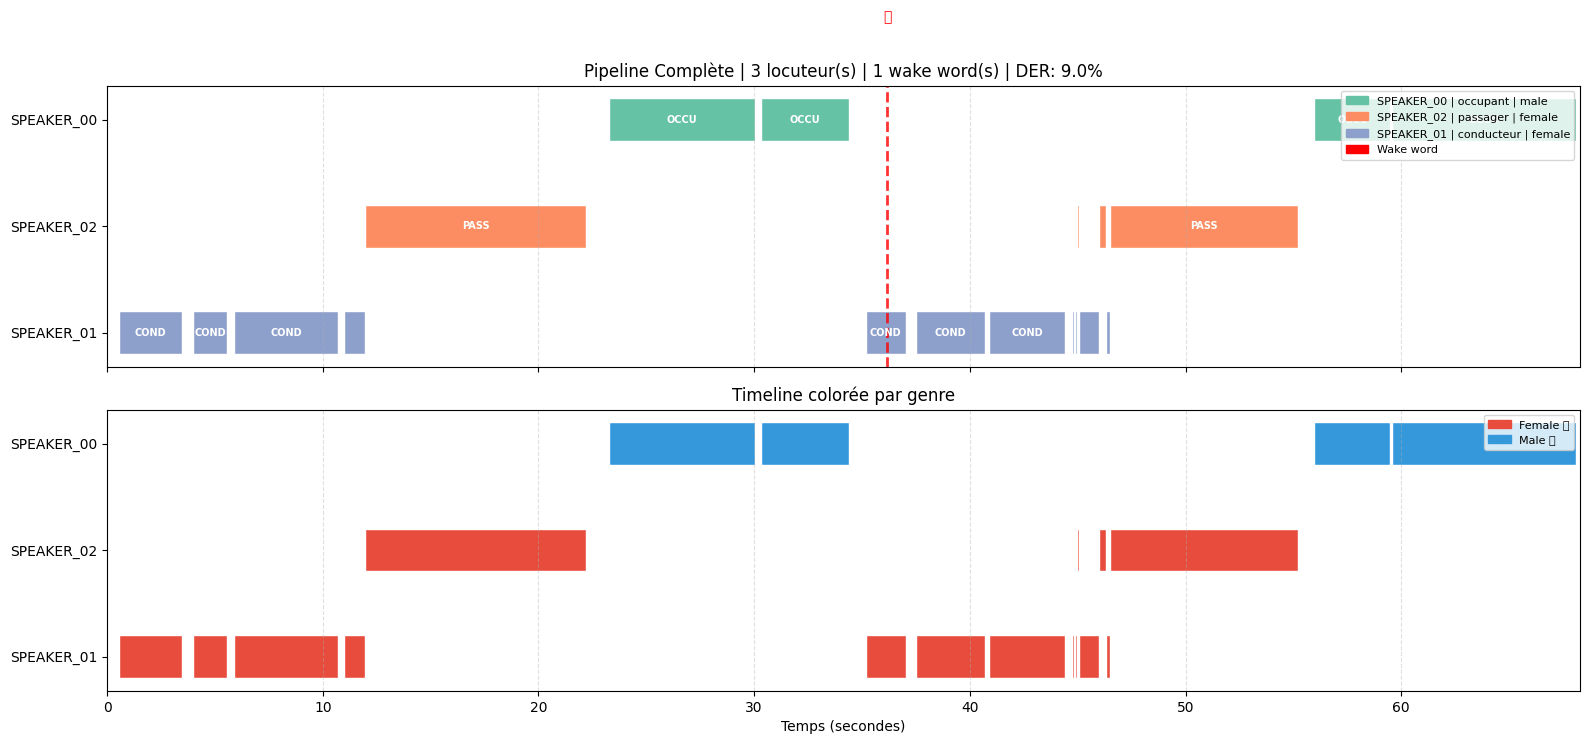

✅ Timeline sauvegardée → pa10_audio/pa10_timeline.png


In [ ]:
GENDER_COLORS = {'female': 'E74C3C', 'male': '3498DB', 'unknown': '95A5A6'}
colors_map    = plt.cm.Set2.colors
spk_colors    = {spk: colors_map[i % len(colors_map)] for i, spk in enumerate(speakers_found)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 3 + len(speakers_found) * 1.5), sharex=True)

# AX1 — Timeline diarisation colorée par rôle
for seg in diarization_segments:
    ax1.barh(y=seg['speaker'], width=seg['end']-seg['start'],
             left=seg['start'], color=spk_colors[seg['speaker']],
             edgecolor='white', height=0.4)
    role = role_mapping.get(seg['speaker'], '')
    if role and seg['end'] - seg['start'] > 1.0:
        ax1.text((seg['start']+seg['end'])/2, seg['speaker'],
                 role[:4].upper(), ha='center', va='center',
                 fontsize=7, color='white', fontweight='bold')
for t in triggers:
    mid = (t['timestamp_start'] + t['timestamp_end']) / 2
    ax1.axvline(x=mid, color='red', linewidth=2, linestyle='--', alpha=0.8)
    ax1.text(mid, len(speakers_found)-0.1, f'🔔', ha='center', va='bottom', fontsize=10, color='red')
patches = [mpatches.Patch(color=spk_colors[s], label=f'{s} | {role_mapping.get(s,"?")} | {gender_results.get(s,{}).get("gender","?")}')
           for s in speakers_found]
patches.append(mpatches.Patch(color='red', label='Wake word'))
ax1.legend(handles=patches, loc='upper right', fontsize=8)
ax1.set_title(f'Pipeline Complète | {len(speakers_found)} locuteur(s) | {len(triggers)} wake word(s) | DER: {der_percent:.1f}%')
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# AX2 — Timeline colorée par genre
gender_patch_colors = {'female': '#E74C3C', 'male': '#3498DB', 'unknown': '#95A5A6'}
for seg in diarization_segments:
    g = gender_results.get(seg['speaker'], {}).get('gender', 'unknown')
    ax2.barh(y=seg['speaker'], width=seg['end']-seg['start'],
             left=seg['start'], color=gender_patch_colors[g],
             edgecolor='white', height=0.4)
gpatches = [
    mpatches.Patch(color='#E74C3C', label='Female 👩'),
    mpatches.Patch(color='#3498DB', label='Male 👨')
]
ax2.legend(handles=gpatches, loc='upper right', fontsize=8)
ax2.set_title('Timeline colorée par genre')
ax2.set_xlabel('Temps (secondes)')
ax2.grid(axis='x', linestyle='--', alpha=0.4)

for ax in [ax1, ax2]:
    ax.set_xlim(0, duration)

plt.tight_layout()
plt.savefig('pa10_audio/pa10_timeline.png', dpi=150)
plt.show()
print('✅ Timeline sauvegardée → pa10_audio/pa10_timeline.png')

## 13. Récapitulatif PA-10

In [ ]:
print('=' * 65)
print('  RÉCAPITULATIF — PA-10 Pipeline Complète')
print('=' * 65)
print(f'  Audio          : {os.path.basename(AUDIO_PATH)} ({duration:.1f}s)')
print(f'  Locuteurs      : {len(speakers_found)} → {speakers_found}')
print(f'  Segments VAD   : {len(speech_timestamps)}')
print(f'  Segments diar  : {len(diarization_segments)}')
print(f'  Wake words     : {len(triggers)}')
print(f'  DER            : {der_percent:.2f}%')
print()
print('  Locuteurs — Rôle | Genre | Âge :')
for spk in speakers_found:
    role = role_mapping.get(spk, '?')
    gr   = gender_results.get(spk, {})
    icon = '👩' if gr.get('gender') == 'female' else '👨'
    print(f'    {icon} {spk} → {role.upper()} | {gr.get("gender","?").upper()} (F0:{gr.get("pitch_f0_mean",0):.0f}Hz) | {gr.get("age_estimate",0):.0f} ans')
print()
if triggers:
    print('  Déclenchements wake word :')
    for t in triggers:
        role = role_mapping.get(t['active_speaker'], '?')
        print(f'    🔔 [{t["timestamp_start"]}s] {t["active_speaker"]} ({role}) — "{t["transcript"][:40]}"')
print()
print('  Modules intégrés : VAD ✅ | Diarisation ✅ | Transcription ✅')
print('                     Wake word ✅ | Conducteur/Passager ✅ | Genre+Âge ✅ | DER ✅')
print('  Émotion          : non implémenté')
print('=' * 65)